# **Section 3: Advanced data cleaning and feature selection**

In this notebook, we will perform advanced data cleaning and feature selection to reduce the dimensionality of our data set.

We will decide which features to keep based on the **training data** only to prevent data leakage. The selected features are then applied to test data.

**Contents:**
1. Outlier sample removal
2. Remove highly correlated features (r > 0.99)
3. Select top features using SelectKBest
4. Save selected feature matrix for further analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set styles
sns.set_style('whitegrid')
sns.set_palette('pastel')

## **1. Load Data**

In [2]:
# Load training features and labels
cnv_train = pd.read_csv('Data/cnv_train.csv', index_col=0)
cnv_test = pd.read_csv("Data/cnv_test.csv", index_col=0)
sxt_train = pd.read_csv('Data/SXT_train.csv', index_col=0)
sxt_test = pd.read_csv("Data/SXT_test.csv", index_col=0)

print(f'Training set shape: {cnv_train.shape}')
print(f'Labels shape: {sxt_train.shape}')
print(f'Resistance distribution:')
print(sxt_train.value_counts())

Training set shape: (177, 11719)
Labels shape: (177, 1)
Resistance distribution:
SXT_binary
1             103
0              74
Name: count, dtype: int64


## **2. Outlier removal**

Remove outlier samples from the analysis. As we saw in notebook 1, several samples had overall values that were above average or a higher than average standard deviation. 
We will identify these samples using thresholds calculated on the training set and remove them from the training and test sets. 

### **2.1 Identify Outliers**
We will remove samples that have a mean, standard deviation and max value +/- 2 times the standard deviation of the distribution of these values in the population. This will thus remove extreme samples.

In [3]:
# Calculate statistics
stats_train = pd.DataFrame({
    'mean': cnv_train.mean(axis=1),
    'std': cnv_train.std(axis=1),
    'max': cnv_train.max(axis=1)
})

# Define outlier thresholds
# Mean
mean_upper = stats_train['mean'].mean() + 2 * stats_train['mean'].std()
mean_lower = stats_train['mean'].mean() - 2 * stats_train['mean'].std()

# Std
std_upper = stats_train['std'].mean() + 2 * stats_train['std'].std()
std_lower = stats_train['std'].mean() - 2 * stats_train['std'].std()

# Max
max_thershold = stats_train['max'].mean() + 2 * stats_train['max'].std()

# Identify outliers
outlier_mean = (stats_train['mean'] > mean_upper) | (stats_train['mean'] < mean_lower)
outlier_std = (stats_train['std'] > std_upper) | (stats_train['std'] < std_lower)
outlier_max = stats_train['max'] > max_thershold

print(f'outliers based on mean: {outlier_mean.sum()}')
print(f'outliers based on std: {outlier_std.sum()}')
print(f'outliers based on max: {outlier_max.sum()}')

# Combine all outliers
all_outliers = outlier_mean | outlier_std | outlier_max

print(f'Total outliers: {all_outliers.sum()}')

outliers based on mean: 1
outliers based on std: 1
outliers based on max: 8
Total outliers: 8


### **2.2 Remove Outliers from training set**

In [4]:
print(f'Before outlier removal: {cnv_train.shape[0]} samples')

# Remove outliers
cnv_train = cnv_train[~all_outliers]
sxt_train = sxt_train[~all_outliers]

print(f'After outlier removal: {cnv_train.shape[0]} samples')
print(f'Removed: {len(all_outliers)} samples')
print(f'\nUpdated resistance distribution:')
print(sxt_train.value_counts())

Before outlier removal: 177 samples
After outlier removal: 169 samples
Removed: 177 samples

Updated resistance distribution:
SXT_binary
1             99
0             70
Name: count, dtype: int64


### **2.3 Remove Outliers from test set**
Let's now use the same thresholds to remove outliers from the test set.

In [5]:
# Calculate statistics for test set
stats_test = pd.DataFrame({
    'mean': cnv_test.mean(axis=1),
    'std': cnv_test.std(axis=1),
    'max': cnv_test.max(axis=1)
})

# Identify outliers
outlier_mean_test = (stats_test['mean'] > mean_upper) | (stats_test['mean'] < mean_lower)
outlier_std_test = (stats_test['std'] > std_upper) | (stats_test['std'] < std_lower)
outlier_max_test = stats_test['max'] > max_thershold

print(f'outliers based on mean: {outlier_mean_test.sum()}')
print(f'outliers based on std: {outlier_std_test.sum()}')
print(f'outliers based on max: {outlier_max_test.sum()}')

# Combine all outliers
all_outliers_test = outlier_mean_test | outlier_std_test | outlier_max_test

print(f'Total outliers: {all_outliers_test.sum()}')

outliers based on mean: 1
outliers based on std: 1
outliers based on max: 1
Total outliers: 1


In [6]:
print(f'Before outlier removal: {cnv_test.shape[0]} samples')

# Remove outliers
cnv_test = cnv_test[~all_outliers_test]
sxt_test = sxt_test[~all_outliers_test]

print(f'After outlier removal: {cnv_test.shape[0]} samples')
print(f'Removed: {len(all_outliers_test)} samples')
print(f'\nUpdated resistance distribution:')
print(sxt_test.value_counts())

Before outlier removal: 50 samples
After outlier removal: 49 samples
Removed: 50 samples

Updated resistance distribution:
SXT_binary
0             29
1             20
Name: count, dtype: int64


## **3. Remove Highly Correlated Features**
Remove features that are highly correlated (r > 0.99) to reduce redundancy.

### **3.1 Identify highly correlated features**
Let's first compute the correlation matrix to see which features correlate. 

In [8]:
from sklearn.cluster import FeatureAgglomeration

# Cluster correlated features together
# n_clusters=None + distance_threshold lets it decide the number of clusters automatically
agglo = FeatureAgglomeration(n_clusters=None, distance_threshold=0.01)  # threshold ~ 1 - 0.99 corr
agglo.fit(cnv_train)

print(f'Reduced from {cnv_train.shape[1]} features to {agglo.n_clusters_} clusters')

# Transform: each cluster is replaced by the mean of its member features
cnv_train_reduced = agglo.transform(cnv_train)

(523, 523)


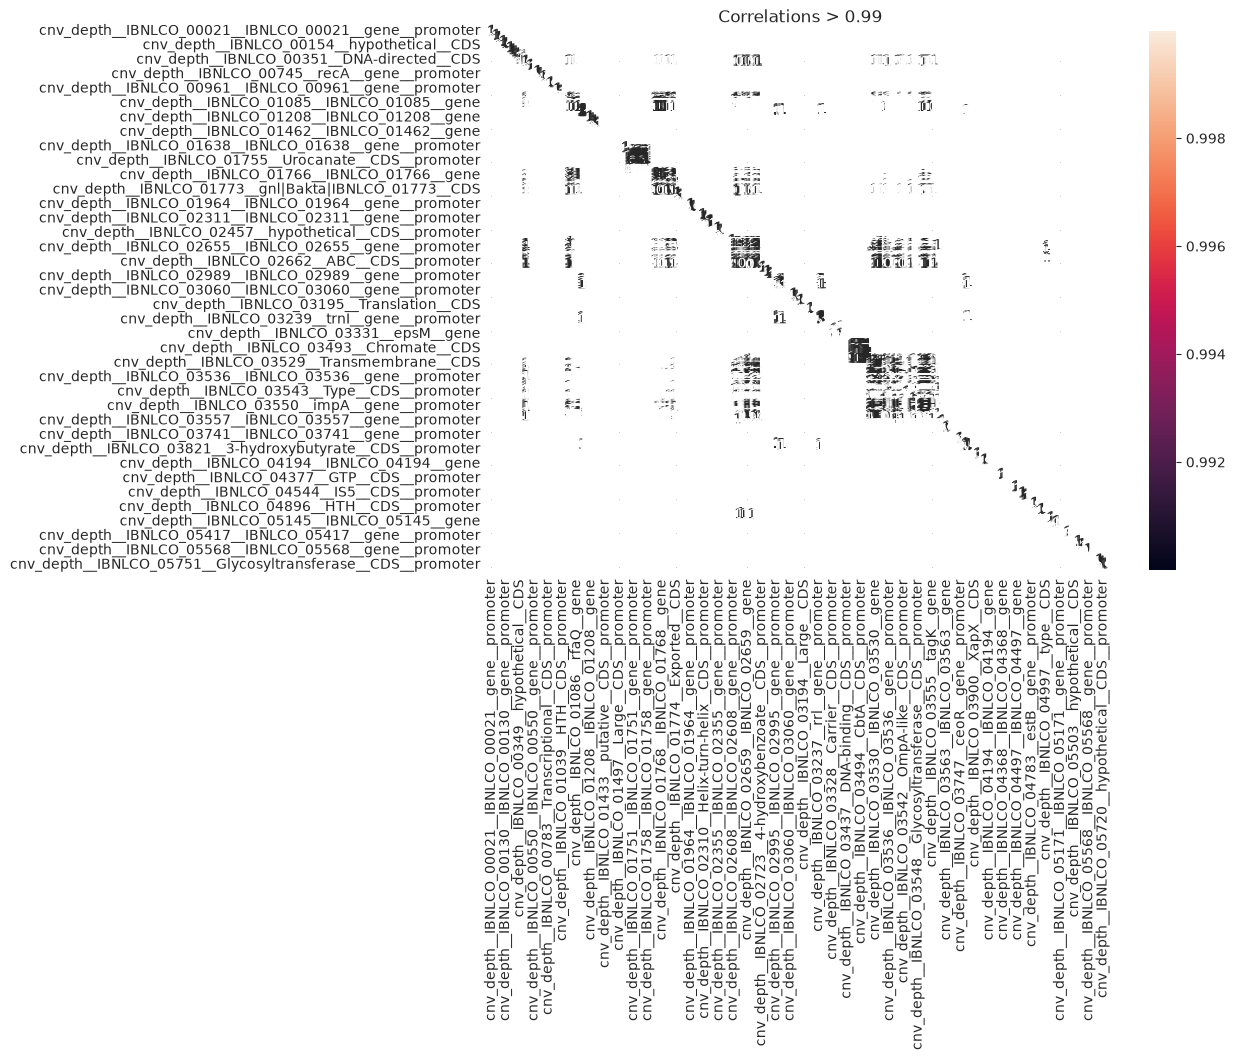

In [9]:
plt.figure(figsize=(10,7))
sns.heatmap(corr_mask, annot=True, linewidths=0.5)
plt.title("Correlations > 0.99")
plt.show()

In [ ]:
# Find pairs above threshold
high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index[upper[col] > 0.99]
]

In [ ]:
print(f'\nTotal highly correlated pairs (r > 0.99): {len(high_corr_pairs)}')

### **3.2 Remove One Feature from Each Correlated Pair**

In [ ]:
# For each correlated pair, keep the feature with higher variance
features_to_remove = set()

for cnv1, cnv2, corr in high_corr_pairs:
    # Remove the one with lower variance
    var1 = cnv_train[cnv1].var()
    var2 = cnv_train[cnv2].var()
    
    if var1 < var2:
        features_to_remove.add(cnv1)
    else:
        features_to_remove.add(cnv2)

print(f'Features before: {cnv_train.shape[1]}')
print(f'Features to remove: {len(features_to_remove)}')

# Remove correlated features
cnv_uncorr = cnv_train.loc[:, ~cnv_train.columns.isin(features_to_remove)].copy()

print(f'Features after: {cnv_uncorr.shape[1]}')
print(f'Removed: {len(features_to_remove)} features due to high correlation')

## **4. Select Features using SelectKBest**

Use ANOVA F-score to identify the most discriminative features.

### **4.1 Score All Features with f_classif**

In [ ]:
# Calculate F-scores for all features
selector_scoring = SelectKBest(score_func=f_classif, k='all')
selector_scoring.fit(cnv_uncorr.values, sxt_train.values.ravel())

# Get scores for all features
feature_scores = selector_scoring.scores_
feature_pvalues = selector_scoring.pvalues_

# Create results dataframe
feature_importance = pd.DataFrame({
    'feature': cnv_uncorr.columns,
    'f_score': feature_scores,
    'p_value': feature_pvalues
})

feature_importance = feature_importance.sort_values('f_score', ascending=False)
feature_importance = feature_importance.dropna()

print(f'Total features scored: {len(feature_pvalues)}')
print(f'Significant features (p<0.05): {(feature_pvalues < 0.05).sum()}')
print(f'\nTop 20 features by F-score:')
print(feature_importance.head(20)[['feature', 'f_score', 'p_value']].to_string(index=False))

### **4.2 Select Significant Features (p < 0.05)**

In [ ]:
# Select all significant features
sig_mask = (feature_pvalues < 0.05)
cnv_selected = cnv_uncorr.loc[:, sig_mask]

print(f'Features before selection: {cnv_uncorr.shape[1]:,}')
print(f'Features after selection: {cnv_selected.shape[1]}')
print(f'\nSelected features maintain {100*cnv_selected.shape[1]/cnv_uncorr.shape[1]:.1f}% of available features')

### **4.3 Visualize Feature Selection Results**

In [ ]:
# Remove NaN scores for visualization
feature_importance_clean = feature_importance.dropna()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Distribution of F-scores
ax = axes[0]
ax.hist(feature_importance_clean['f_score'], bins=50, alpha=0.7, edgecolor='black')
ax.axvline(feature_importance_clean['f_score'].quantile(0.95), 
           color='red', linestyle='--', linewidth=2, label='95th percentile')
ax.set_xlabel('F-Score (ANOVA)', fontweight='bold')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Feature F-Scores', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Elbow plot
cumsum_scores = np.cumsum(feature_importance_clean['f_score'].values)
cumsum_scores_pct = 100 * cumsum_scores / cumsum_scores[-1]

ax = axes[1]
ax.plot(range(1, len(cumsum_scores_pct)+1), cumsum_scores_pct, linewidth=2)
ax.axhline(95, color='red', linestyle='--', linewidth=2, label='95% cumulative score')
ax.set_xlabel('Number of Features', fontweight='bold')
ax.set_ylabel('Cumulative % of F-Score', fontweight='bold')
ax.set_title('Elbow Plot: Feature Importance Accumulation', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Top 20 features
ax = axes[2]
top20 = feature_importance_clean.head(20).sort_values('f_score')
bars = ax.barh(range(len(top20)), top20['f_score'], edgecolor='black', linewidth=1)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f.replace('cnv_depth__', '')[:50] for f in top20['feature']], fontsize=9)
ax.set_xlabel('F-Score (ANOVA)', fontweight='bold')
ax.set_title('Top 20 Most Discriminative Features', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('Figures/04_feature_selection.png', dpi=300, bbox_inches='tight')
plt.show()

## **5. Save Selected Features**

In [ ]:
# Save selected training features
cnv_selected.to_csv('Data/cnv_train_selected.csv')
print(f'Saved: Data/cnv_train_selected.csv ({cnv_selected.shape})')

sxt_train.to_csv("Data/SXT_train_selected.csv")

# Save feature rankings for reference
feature_importance.to_csv('Data/feature_rankings_SXT.csv', index=False)
print(f'Saved: Data/feature_rankings_SXT.csv')

# Save list of selected features for applying to test set
pd.Series(cnv_selected.columns).to_csv('Data/selected_features.csv', index=False)
print(f'Saved: Data/selected_features.csv')

cnv_test_selected = cnv_test[cnv_selected.columns]
cnv_test_selected.to_csv("Data/cnv_test_selected.csv")
print(f'Saved: Data/cnv_test_selected.csv ({cnv_test_selected.shape})')

print(f'\n\nFeature Selection Summary:')
print(f'  Initial features (raw): 23,338')
print(f'  After outlier removal and correlation pruning: {cnv_uncorr.shape[1]:,}')
print(f'  After SelectKBest (p<0.05): {cnv_selected.shape[1]:,}')
print(f'  Dimensionality reduction: {100*(1-cnv_selected.shape[1]/23338):.1f}%')
print(f'\n  Training samples: {cnv_selected.shape[0]}')
print(f'  Resistance distribution:')
print(sxt_train.value_counts())

In [ ]:

sxt_train.shape